In [1]:
import pandas as pd

treedata = pd.read_csv('tree_survey_data.csv')

# removing rows with nan
treedata = treedata.dropna()

print(treedata.shape)

#negative length makes no sense
cond1 = treedata['Tree Trunk Thickness'] > 0
#sum of leaf parts should sum to leaf approximately(floating point error may occur)
cond2 = (treedata['Tree Leaf Size'] - (treedata['Left Sub Leaf Size'] + treedata['Middle Sub Leaf Size'] + treedata['Right Sub Leaf Size']))/treedata['Tree Leaf Size'] < 0.01

treedata = treedata[cond1 & cond2]

print(treedata.shape)

(847, 9)
(647, 9)


In [12]:
#lets understabnd this stuff a bit


print(treedata[(treedata['Latitude']<90) & (treedata['Latitude']>-90)].shape)
print(treedata[(treedata['Longitude']<180) & (treedata['Longitude']>-180)].shape)

#so lets remove incorrect lats and lons


treedata = treedata[(treedata['Latitude']<80) & (treedata['Latitude']>-90)] #I put 80 instead of 90 because no way someone getting data from north pole bruh

treedata = treedata[(treedata['Longitude']<180) & (treedata['Longitude']>-180)]

(637, 9)
(637, 9)


In [13]:
print(treedata['Latitude'].describe())
print(treedata['Longitude'].describe())

count    637.000000
mean      12.133909
std        0.995910
min       10.900000
25%       11.000000
50%       12.900000
75%       13.000000
max       13.200000
Name: Latitude, dtype: float64
count    637.000000
mean      77.841915
std        1.237510
min       76.900000
25%       77.000000
50%       77.600000
75%       77.600000
max       80.300000
Name: Longitude, dtype: float64


FileNotFoundError: No such file or directory: 'Tree_Height_vs_Tree_Thickness.png'

FileNotFoundError: No such file or directory: 'Tree_Height_vs_Tree_Thickness.png'

<IPython.core.display.Image object>

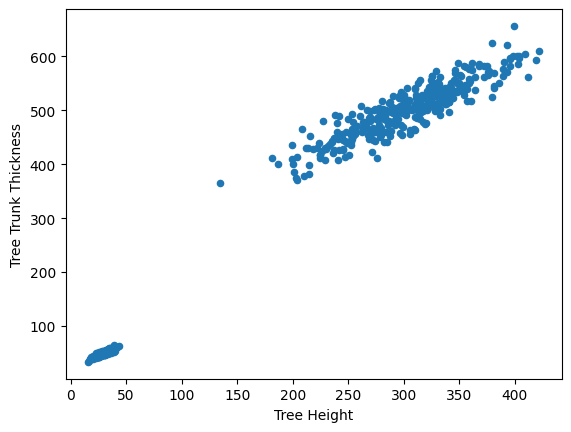

In [43]:
import matplotlib.pyplot as plt 

treedata.plot.scatter(x='Tree Height',y='Tree Trunk Thickness')

<Axes: xlabel='Tree Height', ylabel='Tree Leaf Size'>

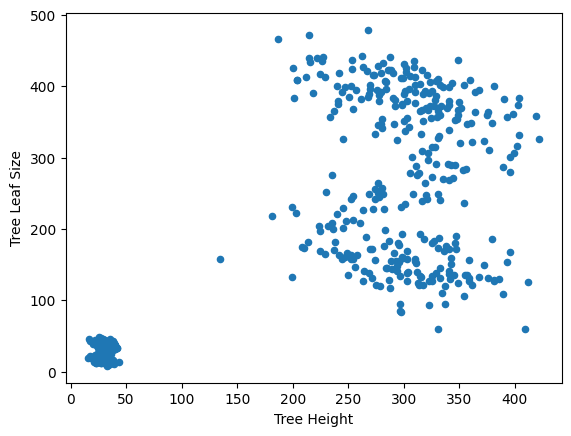

In [15]:
# ok the top one suggest that there are two types of relationships between trunk thickness and height 
# depending upon the height lets see other relations
treedata.plot.scatter(x='Tree Height',y='Tree Leaf Size')

<Axes: xlabel='Tree Trunk Thickness', ylabel='Tree Leaf Size'>

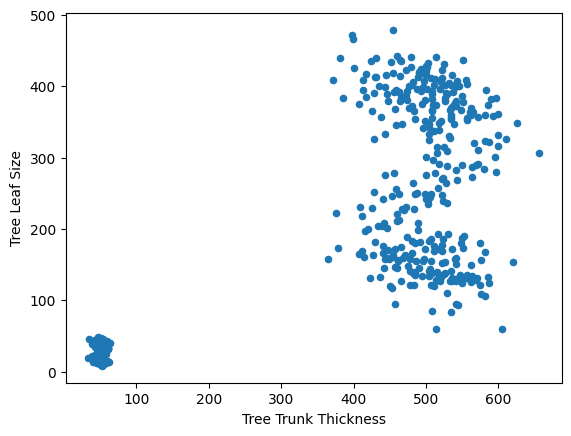

In [16]:
#seems like no real relation

treedata.plot.scatter(x='Tree Trunk Thickness',y='Tree Leaf Size')

In [17]:
# agaion no real relation

# so it seems that there are two types of trees-> short trees and big trees and they have different relations of tree trunk size and tree trunk lets analyse this more

shorttreedata = treedata[treedata['Tree Height'] < 100]


talltreedata = treedata[treedata['Tree Height'] > 100]



<Axes: xlabel='Tree Height', ylabel='Tree Leaf Size'>

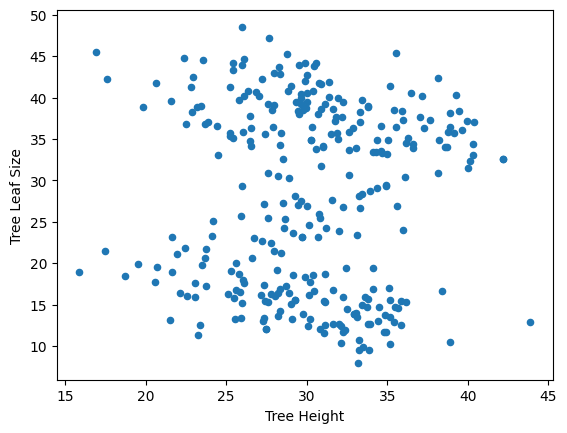

In [18]:
shorttreedata.plot.scatter(x='Tree Height',y='Tree Leaf Size')

<Axes: xlabel='Tree Height', ylabel='Tree Leaf Size'>

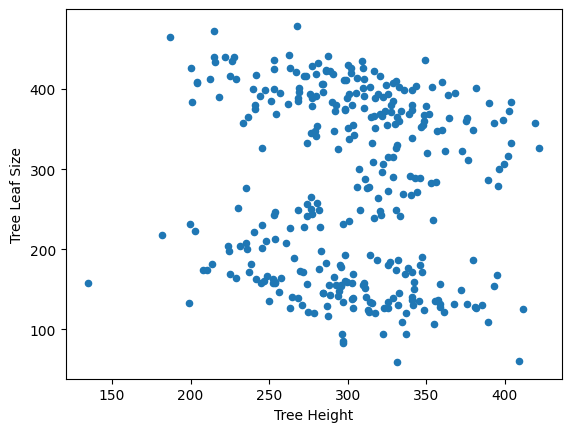

In [19]:
talltreedata.plot.scatter(x='Tree Height',y='Tree Leaf Size')

<Axes: xlabel='Tree Height', ylabel='Tree Trunk Thickness'>

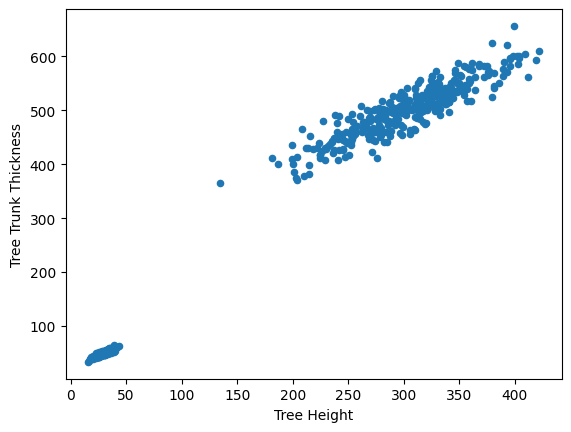

In [20]:
treedata.plot.scatter(x='Tree Height',y='Tree Trunk Thickness')

<Axes: xlabel='Tree Height', ylabel='Tree Trunk Thickness'>

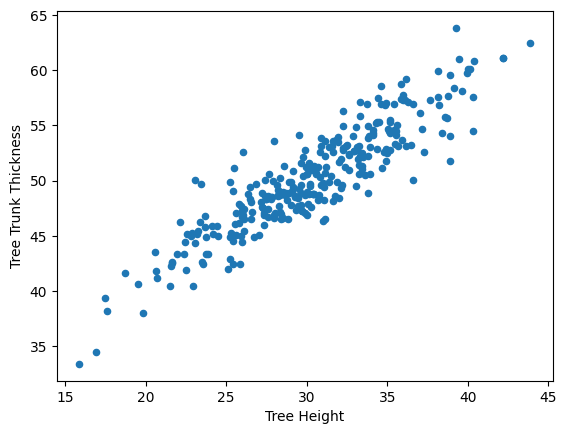

In [21]:
shorttreedata.plot.scatter(x='Tree Height',y='Tree Trunk Thickness')

<Axes: xlabel='Tree Height', ylabel='Tree Trunk Thickness'>

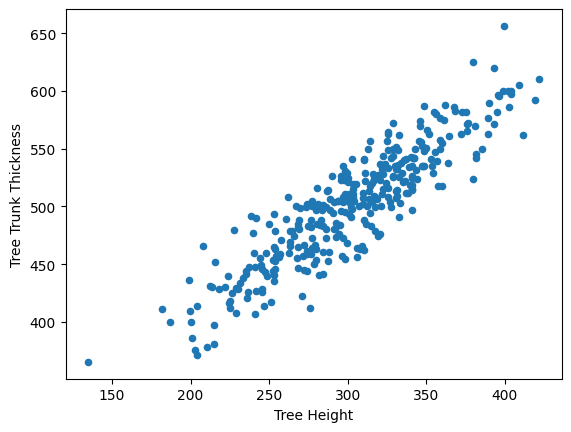

In [22]:
talltreedata.plot.scatter(x='Tree Height',y='Tree Trunk Thickness')

(array([0.00244047, 0.01464282, 0.0170833 , 0.05124989, 0.03660706,
        0.04392847, 0.04636895, 0.02684518, 0.02440471, 0.01464282,
        0.00976188, 0.02440471, 0.0170833 , 0.00976188, 0.02196424,
        0.01464282, 0.01464282, 0.00488094, 0.02684518, 0.04880942,
        0.03660706, 0.04636895, 0.05124989, 0.03904753, 0.03172612,
        0.02440471, 0.01952377, 0.01464282, 0.        , 0.00488094]),
 array([ 7.97      ,  9.32233333, 10.67466667, 12.027     , 13.37933333,
        14.73166667, 16.084     , 17.43633333, 18.78866667, 20.141     ,
        21.49333333, 22.84566667, 24.198     , 25.55033333, 26.90266667,
        28.255     , 29.60733333, 30.95966667, 32.312     , 33.66433333,
        35.01666667, 36.369     , 37.72133333, 39.07366667, 40.426     ,
        41.77833333, 43.13066667, 44.483     , 45.83533333, 47.18766667,
        48.54      ]),
 <BarContainer object of 30 artists>)

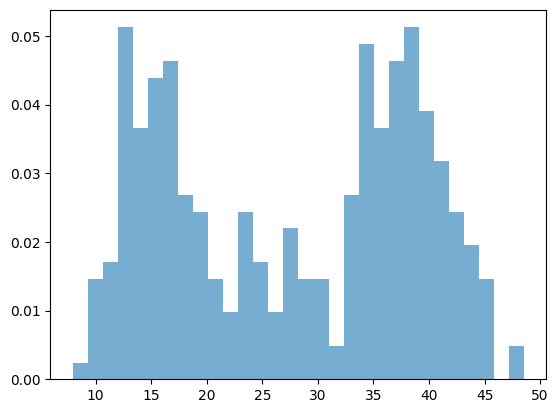

In [32]:
#lets check gaussianality

y = shorttreedata['Tree Leaf Size']
z = talltreedata['Tree Leaf Size']

plt.hist(y,bins = 30,alpha=0.6,density=True)

(array([0.00042802, 0.00042802, 0.00064203, 0.00064203, 0.0038522 ,
        0.00535027, 0.00363818, 0.00470824, 0.00363818, 0.0019261 ,
        0.00171209, 0.00085604, 0.0019261 , 0.00256813, 0.00107005,
        0.0019261 , 0.00171209, 0.00128407, 0.00128407, 0.00214011,
        0.00214011, 0.00428022, 0.00470824, 0.00513626, 0.00470824,
        0.0038522 , 0.00321016, 0.00107005, 0.        , 0.00064203]),
 array([ 59.2 ,  73.19,  87.18, 101.17, 115.16, 129.15, 143.14, 157.13,
        171.12, 185.11, 199.1 , 213.09, 227.08, 241.07, 255.06, 269.05,
        283.04, 297.03, 311.02, 325.01, 339.  , 352.99, 366.98, 380.97,
        394.96, 408.95, 422.94, 436.93, 450.92, 464.91, 478.9 ]),
 <BarContainer object of 30 artists>)

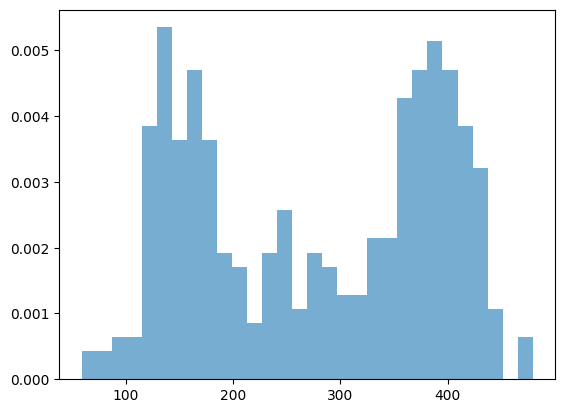

In [31]:

plt.hist(z,bins = 30,alpha=0.6,density=True)

(array([0.02693073, 0.1615844 , 0.18851513, 0.56554538, 0.40396099,
        0.48475319, 0.51168392, 0.29623806, 0.26930733, 0.1615844 ,
        0.10772293, 0.26930733, 0.18851513, 0.10772293, 0.24237659,
        0.1615844 , 0.1615844 , 0.05386147, 0.29623806, 0.53861465,
        0.40396099, 0.51168392, 0.56554538, 0.43089172, 0.35009952,
        0.26930733, 0.21544586, 0.1615844 , 0.        , 0.05386147]),
 array([-1.79681494, -1.6742661 , -1.55171726, -1.42916842, -1.30661958,
        -1.18407074, -1.0615219 , -0.93897306, -0.81642422, -0.69387538,
        -0.57132654, -0.4487777 , -0.32622886, -0.20368002, -0.08113118,
         0.04141766,  0.1639665 ,  0.28651534,  0.40906418,  0.53161302,
         0.65416186,  0.7767107 ,  0.89925954,  1.02180838,  1.14435722,
         1.26690606,  1.3894549 ,  1.51200374,  1.63455258,  1.75710142,
         1.87965026]),
 <BarContainer object of 30 artists>)

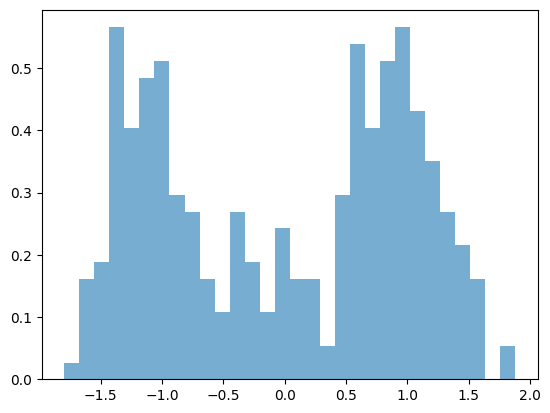

In [38]:
#both look quite similiar which suggests that the 


ynor = (y - y.mean())/y.std()

znor = (z - z.mean())/z.std()


plt.hist(ynor,bins = 30,alpha=0.6,density=True)

(array([0.0480374 , 0.0480374 , 0.07205609, 0.07205609, 0.43233657,
        0.60046746, 0.40831787, 0.52841136, 0.40831787, 0.21616828,
        0.19214959, 0.09607479, 0.21616828, 0.28822438, 0.12009349,
        0.21616828, 0.19214959, 0.14411219, 0.14411219, 0.24018698,
        0.24018698, 0.48037396, 0.52841136, 0.57644876, 0.52841136,
        0.43233657, 0.36028047, 0.12009349, 0.        , 0.07205609]),
 array([-1.9480529 , -1.82339952, -1.69874614, -1.57409276, -1.44943937,
        -1.32478599, -1.20013261, -1.07547923, -0.95082584, -0.82617246,
        -0.70151908, -0.5768657 , -0.45221231, -0.32755893, -0.20290555,
        -0.07825217,  0.04640122,  0.1710546 ,  0.29570798,  0.42036136,
         0.54501475,  0.66966813,  0.79432151,  0.91897489,  1.04362828,
         1.16828166,  1.29293504,  1.41758842,  1.54224181,  1.66689519,
         1.79154857]),
 <BarContainer object of 30 artists>)

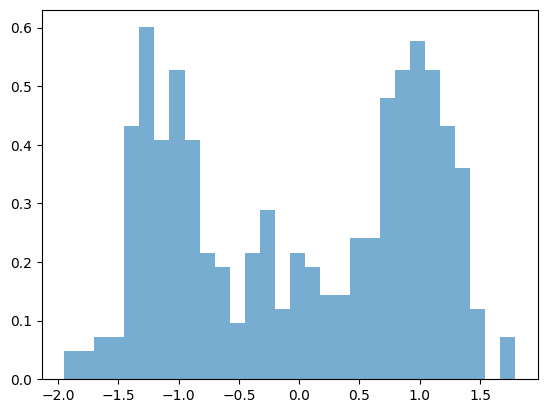

In [39]:

plt.hist(znor,bins = 30,alpha=0.6,density=True)

(array([0.00353733, 0.01061199, 0.        , 0.00707466, 0.00353733,
        0.01061199, 0.02829865, 0.03183598, 0.03891064, 0.01061199,
        0.08843328, 0.03183598, 0.08489595, 0.07074662, 0.07782129,
        0.08843328, 0.07428396, 0.07074662, 0.06720929, 0.0565973 ,
        0.06367196, 0.04598531, 0.02122399, 0.01414932, 0.02829865,
        0.02122399, 0.01061199, 0.        , 0.00707466, 0.00353733]),
 array([15.89 , 16.823, 17.756, 18.689, 19.622, 20.555, 21.488, 22.421,
        23.354, 24.287, 25.22 , 26.153, 27.086, 28.019, 28.952, 29.885,
        30.818, 31.751, 32.684, 33.617, 34.55 , 35.483, 36.416, 37.349,
        38.282, 39.215, 40.148, 41.081, 42.014, 42.947, 43.88 ]),
 <BarContainer object of 30 artists>)

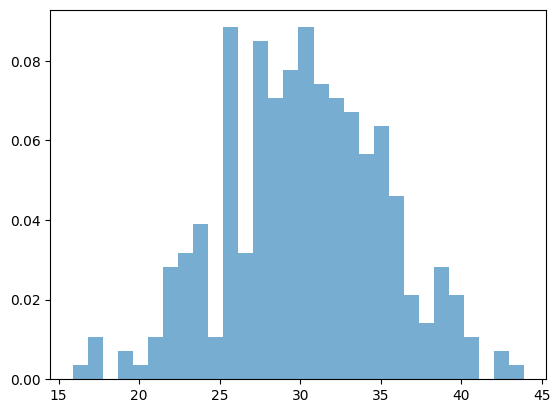

In [40]:

hy = shorttreedata['Tree Height']
hz = talltreedata['Tree Height']

plt.hist(hy,bins = 30,alpha=0.6,density=True)

(array([0.00031285, 0.        , 0.        , 0.        , 0.00031285,
        0.00031285, 0.00125142, 0.00156427, 0.00187712, 0.00312854,
        0.00281569, 0.00437995, 0.00500566, 0.00437995, 0.00656993,
        0.00719564, 0.00688279, 0.0081342 , 0.00844706, 0.00782135,
        0.0081342 , 0.00625708, 0.00563137, 0.00375425, 0.00156427,
        0.00281569, 0.00125142, 0.00250283, 0.00156427, 0.00062571]),
 array([134.8 , 144.37, 153.94, 163.51, 173.08, 182.65, 192.22, 201.79,
        211.36, 220.93, 230.5 , 240.07, 249.64, 259.21, 268.78, 278.35,
        287.92, 297.49, 307.06, 316.63, 326.2 , 335.77, 345.34, 354.91,
        364.48, 374.05, 383.62, 393.19, 402.76, 412.33, 421.9 ]),
 <BarContainer object of 30 artists>)

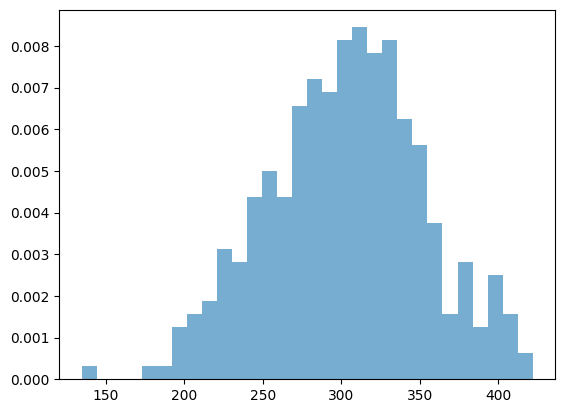

In [41]:

plt.hist(hz,bins = 30,alpha=0.6,density=True)

In [ ]:
#both look approximate gaussian